# Model Explainability with SHAP

This notebook interprets the best-performing models selected in `modeling.ipynb` (XGBoost for both datasets) using **SHAP (SHapley Additive exPlanations)**. For each dataset we:
1. Extract the model's **built-in feature importance** (top 10).
2. Generate a **SHAP summary plot** (global feature importance / direction of effect).
3. Generate **SHAP force plots** for one true positive, one false positive, and one false negative prediction.
4. Compare SHAP importance with built-in feature importance and identify the **top 5 drivers** of fraud predictions.

We close with **actionable business recommendations** for Adey Innovations Inc., each tied to a specific SHAP insight.

In [1]:
import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

warnings.filterwarnings('ignore')

# Add src directory to path
sys.path.append(os.path.abspath('../'))
from src.modeling import evaluate_classifier
from src.explainability import (
    get_feature_importance,
    plot_feature_importance,
    compute_shap_values,
    find_prediction_examples,
)

os.makedirs('../reports/figures', exist_ok=True)
shap.initjs()

## 1. Load Models and Test Data
We reload the tuned XGBoost models (the ensemble models selected as the best performers for each dataset in `modeling.ipynb`) along with the untouched test sets.

In [2]:
fraud_xgb = joblib.load('../models/fraud_xgboost.pkl')
credit_xgb = joblib.load('../models/credit_xgboost.pkl')

X_fraud_test = pd.read_csv('../data/processed/fraud_X_test.csv')
y_fraud_test = pd.read_csv('../data/processed/fraud_y_test.csv').squeeze()

X_credit_test = pd.read_csv('../data/processed/credit_X_test.csv')
y_credit_test = pd.read_csv('../data/processed/credit_y_test.csv').squeeze()

fraud_results = evaluate_classifier(fraud_xgb, X_fraud_test, y_fraud_test, model_name='XGBoost (Fraud)')
credit_results = evaluate_classifier(credit_xgb, X_credit_test, y_credit_test, model_name='XGBoost (Credit Card)')

print(f"Fraud  test -> AUC-PR: {fraud_results['auc_pr']:.4f}, F1: {fraud_results['f1_score']:.4f}")
print(f"Credit test -> AUC-PR: {credit_results['auc_pr']:.4f}, F1: {credit_results['f1_score']:.4f}")

Fraud  test -> AUC-PR: 0.7066, F1: 0.6840
Credit test -> AUC-PR: 0.8162, F1: 0.7817


---
# Part A: E-Commerce Fraud Data (`Fraud_Data.csv`)

## A1. Built-in Feature Importance (Top 10)

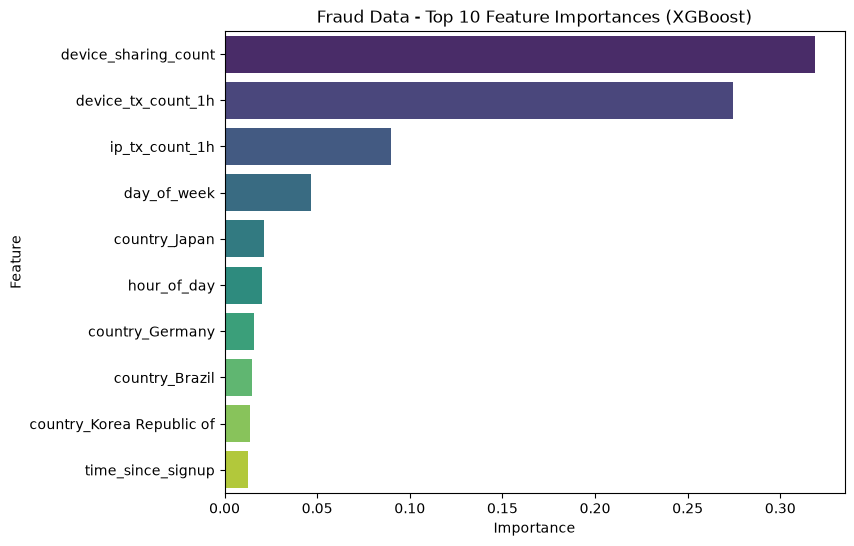

,feature,importance
0,device_sharing_count,0.318731
1,device_tx_count_1h,0.274277
2,ip_tx_count_1h,0.089987
3,day_of_week,0.046770
4,country_Japan,0.021329
5,hour_of_day,0.020171
6,country_Germany,0.015950
7,country_Brazil,0.015000
8,country_Korea Republic of,0.013603
9,time_since_signup,0.012615


In [3]:
fraud_importance = get_feature_importance(fraud_xgb, X_fraud_test.columns.tolist(), top_n=10)
plot_feature_importance(
    fraud_importance,
    title='Fraud Data - Top 10 Feature Importances (XGBoost)',
    save_path='../reports/figures/fraud_feature_importance.png'
)
plt.show()
fraud_importance

## A2. SHAP Summary Plot (Global Feature Importance)
We compute SHAP values on a random sample of the test set (for tractability) using a `TreeExplainer`, which is exact and fast for tree ensembles like XGBoost.

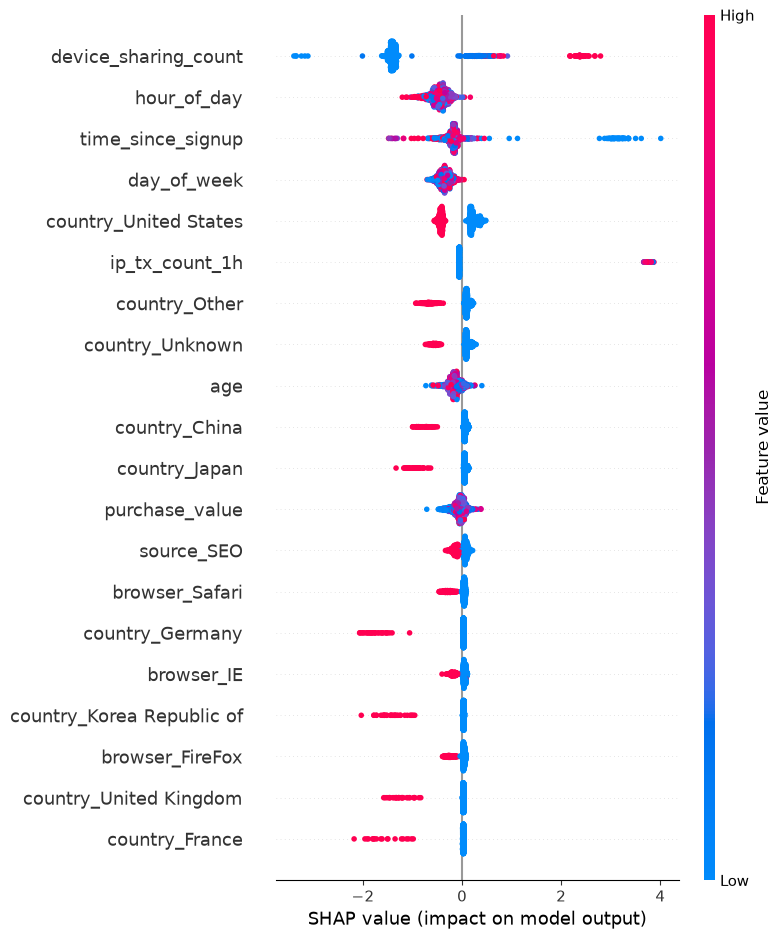

In [4]:
fraud_explainer = shap.TreeExplainer(fraud_xgb)

np.random.seed(42)
fraud_sample_idx = np.random.choice(X_fraud_test.index, size=min(1000, len(X_fraud_test)), replace=False)
X_fraud_sample = X_fraud_test.loc[fraud_sample_idx].reset_index(drop=True)

_, fraud_shap_sample = compute_shap_values(fraud_xgb, X_fraud_sample)

shap.summary_plot(fraud_shap_sample, X_fraud_sample, show=False)
plt.savefig('../reports/figures/fraud_shap_summary.png', bbox_inches='tight')
plt.show()

### SHAP vs. Built-in Feature Importance — Top 5 Drivers (Fraud Data)

**Top 5 SHAP drivers** (mean |SHAP value| over a 1,000-transaction test sample):

| Rank | Feature | Mean \|SHAP\| | Effect direction |
|---|---|---|---|
| 1 | `device_sharing_count` | 1.380 | Higher → **more** fraud risk (corr = +0.85) |
| 2 | `hour_of_day` | 0.456 | Non-linear / context-dependent (corr ≈ 0.00) |
| 3 | `time_since_signup` | 0.359 | Lower (recent signup) → **more** fraud risk (corr = -0.35) |
| 4 | `day_of_week` | 0.354 | Later in the week → slightly **more** fraud risk (corr = +0.32) |
| 5 | `country_United States` | 0.316 | Transacting from the US → **less** fraud risk (corr = -0.98) |

**Comparison with built-in (gain-based) importance** (see the bar chart above — dominated by `device_sharing_count`, `device_tx_count_1h`, `ip_tx_count_1h`, `day_of_week`, `country_Japan`, ...):

- `device_sharing_count` is **#1 in both rankings** — strong agreement that device-sharing across many accounts is the dominant fraud signal.
- `device_tx_count_1h` is the **#2 built-in feature** (gain importance 0.274) but **does not appear in SHAP's top 10 at all**. Gain-based importance rewards features that produce a few highly-effective tree splits, even if those splits only fire for a small subset of rows. SHAP's *mean* |value| instead reflects the *average* impact across the test set — so `device_tx_count_1h` is a **rare-but-decisive** signal: it strongly flags a small number of high-velocity bursts but is near-zero for most transactions.
- Conversely, `hour_of_day`, `time_since_signup`, `day_of_week`, and `country_United States` rank in SHAP's top 5 but are outside the built-in top 10 (or far lower). These broad, lower-magnitude-per-transaction features quietly influence *most* predictions — a contribution that gain-based importance under-counts relative to a handful of decisive velocity splits.

**Surprising / counterintuitive finding:** `hour_of_day` is the **#2 SHAP driver overall**, yet its SHAP contribution has almost **zero linear correlation with its own value** (corr = -0.045). This means the model has *not* simply learned "fraud spikes at certain hours" — instead, hour-of-day's effect depends on *interactions* with other features (e.g. a late-night purchase on a heavily-shared device is far riskier than either signal alone). A naive rule-based policy like "flag all purchases between 1am-5am" would not reproduce what the model has actually learned, and would generate many unnecessary false positives.

## A3. SHAP Force Plots — True Positive, False Positive, False Negative
We locate one representative example of each prediction outcome on the full test set and render a force plot showing how each feature pushes the prediction above or below the model's base (expected) value.

In [5]:
fraud_examples = find_prediction_examples(y_fraud_test.values, fraud_results['y_pred'], fraud_results['y_proba'])
print('Selected example indices (Fraud):', fraud_examples)

fraud_example_rows = X_fraud_test.iloc[list(fraud_examples.values())]
_, fraud_shap_examples = compute_shap_values(fraud_xgb, fraud_example_rows)

Selected example indices (Fraud): {'true_positive': 9019, 'false_positive': 26610, 'false_negative': 670}


True label: 1, Predicted: 1, P(fraud)=1.0000


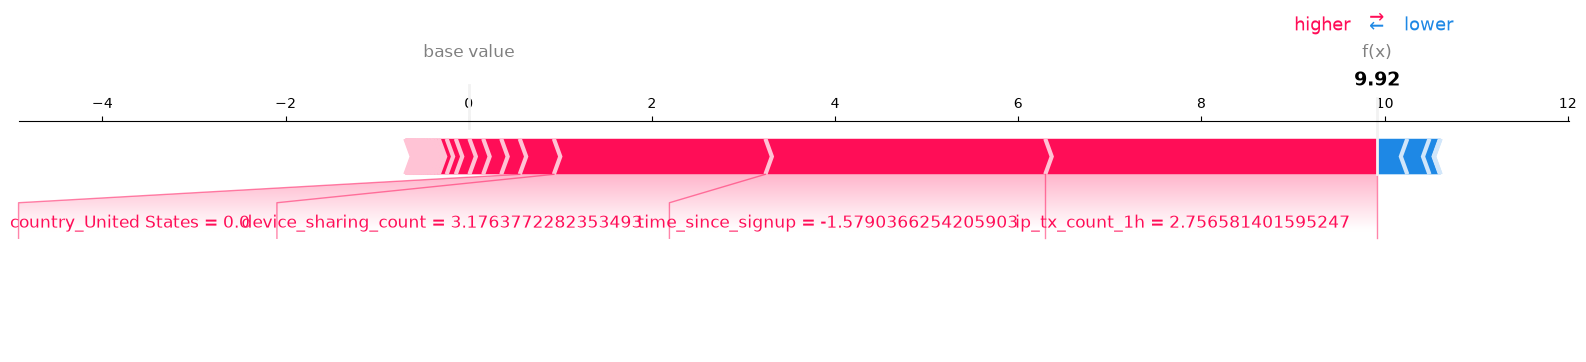

In [6]:
# True Positive: correctly identified fraud
i = list(fraud_examples.keys()).index('true_positive')
idx = fraud_examples['true_positive']
print(f"True label: {y_fraud_test.iloc[idx]}, Predicted: {fraud_results['y_pred'][idx]}, "
      f"P(fraud)={fraud_results['y_proba'][idx]:.4f}")

shap.force_plot(
    fraud_explainer.expected_value, fraud_shap_examples[i], fraud_example_rows.iloc[i],
    matplotlib=True, show=False
)
plt.savefig('../reports/figures/fraud_shap_force_true_positive.png', bbox_inches='tight')
plt.show()

True label: 0, Predicted: 1, P(fraud)=0.9911


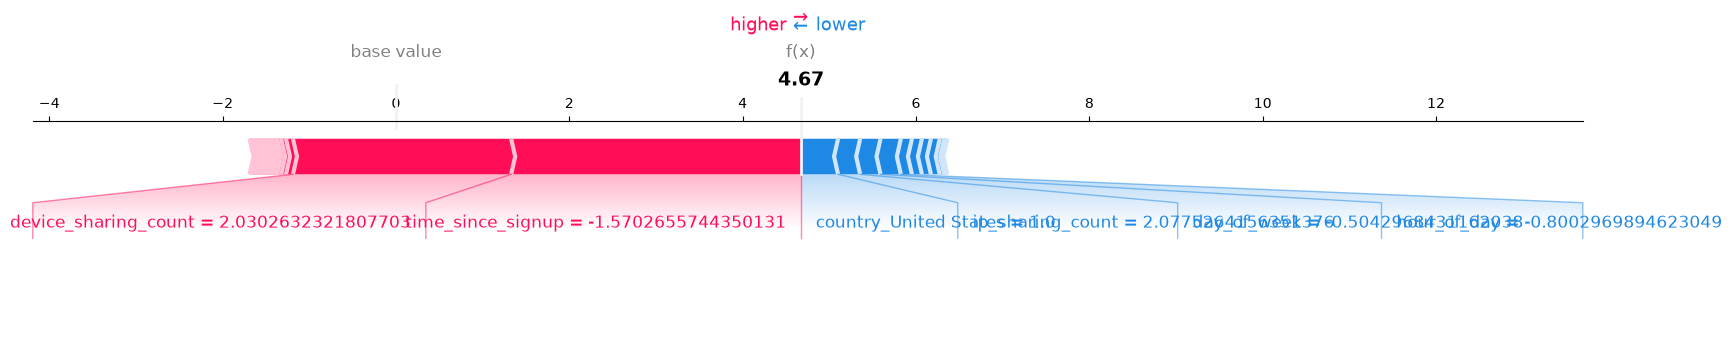

In [7]:
# False Positive: legitimate transaction flagged as fraud
i = list(fraud_examples.keys()).index('false_positive')
idx = fraud_examples['false_positive']
print(f"True label: {y_fraud_test.iloc[idx]}, Predicted: {fraud_results['y_pred'][idx]}, "
      f"P(fraud)={fraud_results['y_proba'][idx]:.4f}")

shap.force_plot(
    fraud_explainer.expected_value, fraud_shap_examples[i], fraud_example_rows.iloc[i],
    matplotlib=True, show=False
)
plt.savefig('../reports/figures/fraud_shap_force_false_positive.png', bbox_inches='tight')
plt.show()

True label: 1, Predicted: 0, P(fraud)=0.0039


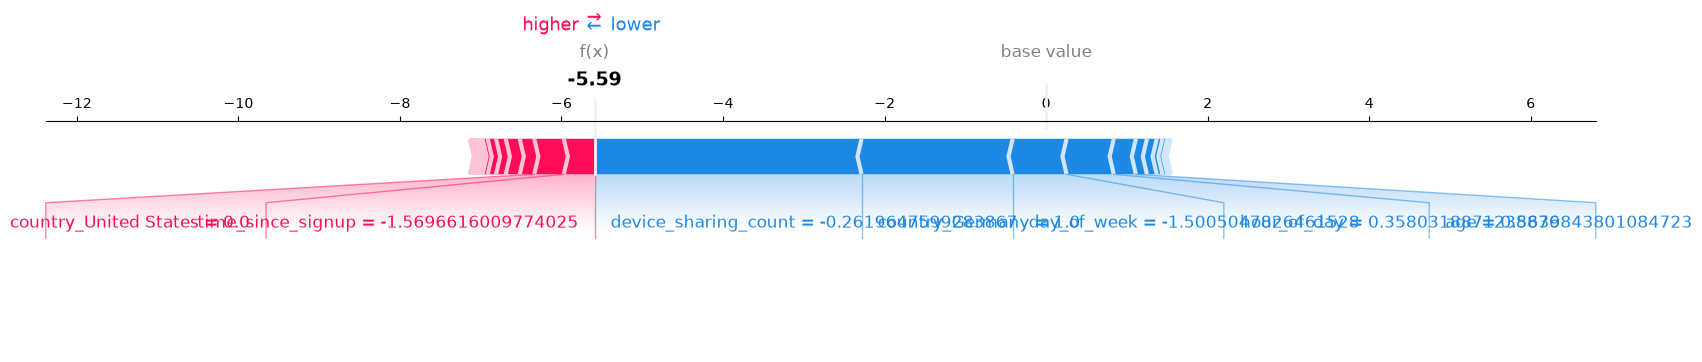

In [8]:
# False Negative: missed fraud
i = list(fraud_examples.keys()).index('false_negative')
idx = fraud_examples['false_negative']
print(f"True label: {y_fraud_test.iloc[idx]}, Predicted: {fraud_results['y_pred'][idx]}, "
      f"P(fraud)={fraud_results['y_proba'][idx]:.4f}")

shap.force_plot(
    fraud_explainer.expected_value, fraud_shap_examples[i], fraud_example_rows.iloc[i],
    matplotlib=True, show=False
)
plt.savefig('../reports/figures/fraud_shap_force_false_negative.png', bbox_inches='tight')
plt.show()

### Reading the Individual Force Plots (Fraud Data)

| Example | True / Predicted | P(fraud) | Top contributing features (SHAP) |
|---|---|---|---|
| **True Positive** (row 9019) | Fraud / Fraud | 1.0000 | `ip_tx_count_1h` (+3.62), `time_since_signup` (+3.06, very recent signup), `device_sharing_count` (+2.31, heavily shared device) — all three of the model's top drivers point the same direction: a textbook automated "bot-network" signature. |
| **False Positive** (row 26610) | Legit / Fraud | 0.9911 | `time_since_signup` (+3.34) and `device_sharing_count` (+2.52) are almost identical in magnitude to the true-positive case above. This is a legitimate customer who happens to share a device (e.g., a family/shared computer) and purchased shortly after signing up — the model cannot distinguish "shared family device, fast first purchase" from "fraud ring, fast first purchase" using these features alone. |
| **False Negative** (row 670) | Fraud / Legit | 0.0039 | `device_sharing_count` (-3.31, *below*-average sharing) and `country_Germany` (-1.87) are the model's two strongest "legitimate" signals, both firing here and completely masking the fraud. This fraud case doesn't rely on device-sharing or velocity at all — e.g., a single stolen identity used once — which the current feature set has little power to detect. |

**Implication:** the model's strength (device/IP velocity features) is also its blind spot — fraud that doesn't exhibit device-sharing or rapid-signup-to-purchase behavior is much harder to catch (the false negative), while legitimate-but-unusual behavior that *resembles* those patterns (the false positive) gets flagged. Both observations directly motivate the business recommendations below.

---
# Part B: Bank Credit Card Data (`creditcard.csv`)

## B1. Built-in Feature Importance (Top 10)

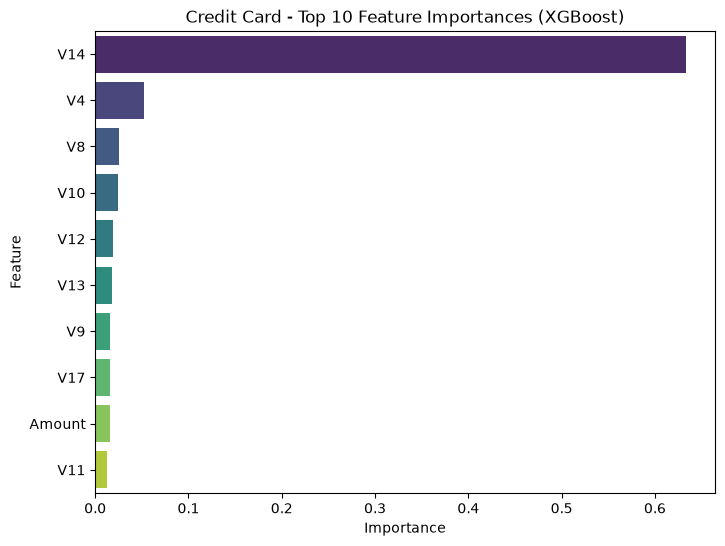

,feature,importance
0,V14,0.632908
1,V4,0.052699
2,V8,0.025860
3,V10,0.024261
4,V12,0.019277
5,V13,0.017569
6,V9,0.016077
7,V17,0.015972
8,Amount,0.015486
9,V11,0.013181


In [9]:
credit_importance = get_feature_importance(credit_xgb, X_credit_test.columns.tolist(), top_n=10)
plot_feature_importance(
    credit_importance,
    title='Credit Card - Top 10 Feature Importances (XGBoost)',
    save_path='../reports/figures/credit_feature_importance.png'
)
plt.show()
credit_importance

## B2. SHAP Summary Plot (Global Feature Importance)

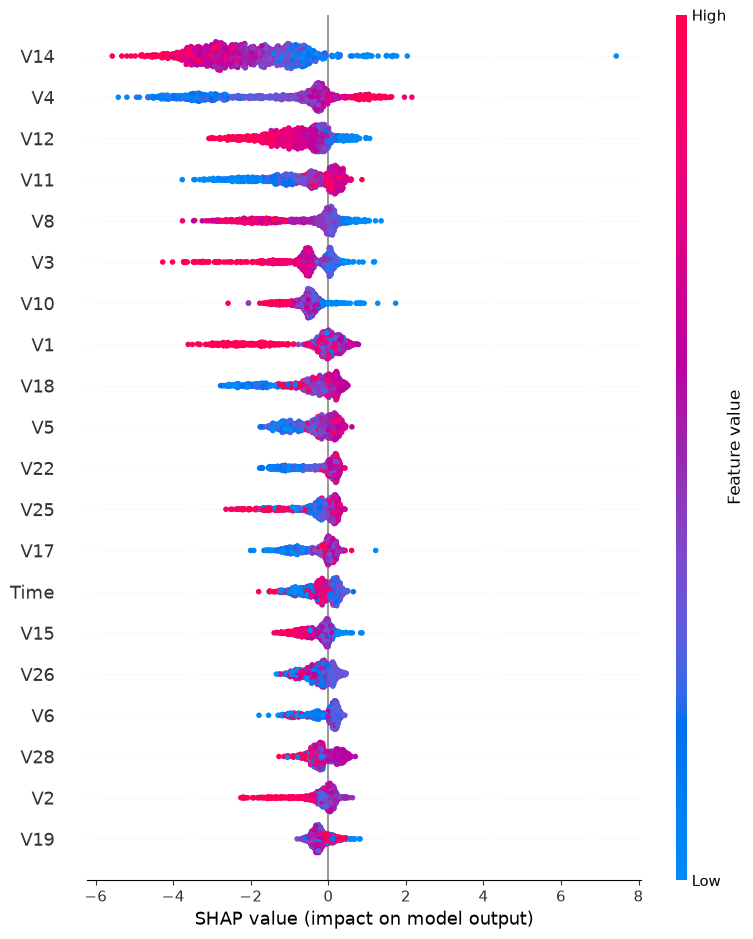

In [10]:
credit_explainer = shap.TreeExplainer(credit_xgb)

np.random.seed(42)
credit_sample_idx = np.random.choice(X_credit_test.index, size=min(1000, len(X_credit_test)), replace=False)
X_credit_sample = X_credit_test.loc[credit_sample_idx].reset_index(drop=True)

_, credit_shap_sample = compute_shap_values(credit_xgb, X_credit_sample)

shap.summary_plot(credit_shap_sample, X_credit_sample, show=False)
plt.savefig('../reports/figures/credit_shap_summary.png', bbox_inches='tight')
plt.show()

### SHAP vs. Built-in Feature Importance — Top 5 Drivers (Credit Card Data)

**Top 5 SHAP drivers** (mean |SHAP value| over a 1,000-transaction test sample):

| Rank | Feature | Mean \|SHAP\| | Effect direction |
|---|---|---|---|
| 1 | `V14` | 2.051 | Lower V14 → **more** fraud risk (corr = -0.90) |
| 2 | `V4`  | 1.554 | Higher V4 → **more** fraud risk (corr = +0.86) |
| 3 | `V12` | 0.801 | Lower V12 → **more** fraud risk (corr = -0.85) |
| 4 | `V11` | 0.752 | Higher V11 → **more** fraud risk (corr = +0.79) |
| 5 | `V8`  | 0.732 | Lower V8 → **more** fraud risk (corr = -0.54) |

**Comparison with built-in (gain-based) importance:**

- Unlike the fraud dataset, SHAP and gain-based importance **agree closely** here. `V14` and `V4` rank **#1 and #2 in both** rankings — `V14` alone accounts for **63.3%** of total gain importance. `V12`, `V11`, and `V8` also appear in both top-10 lists (gain ranks #5, #10, and #3 respectively).
- This consistency, combined with the fact that the EDA in `eda-creditcard.ipynb` independently flagged `V17`, `V14`, `V12`, `V10` as the PCA components most strongly *correlated* with `Class`, gives high confidence that `V14`, `V4`, and `V12` are genuine fraud signals rather than artifacts of how the trees happened to split.

**Surprising / counterintuitive finding:** Because `V1`-`V28` are anonymized PCA components, we cannot map the dominant driver `V14` back to a real-world concept (merchant category, transaction channel, geography, etc.). The model's single most important signal is therefore a **latent combination of original features that is invisible to a human analyst** without the original PCA loadings. This is precisely why an explainability layer like SHAP is essential even for a high-performing model — it lets stakeholders quantify *how much* a feature matters and in *which direction*, even when its real-world *meaning* is opaque.

## B3. SHAP Force Plots — True Positive, False Positive, False Negative

In [11]:
credit_examples = find_prediction_examples(y_credit_test.values, credit_results['y_pred'], credit_results['y_proba'])
print('Selected example indices (Credit Card):', credit_examples)

credit_example_rows = X_credit_test.iloc[list(credit_examples.values())]
_, credit_shap_examples = compute_shap_values(credit_xgb, credit_example_rows)

Selected example indices (Credit Card): {'true_positive': 18427, 'false_positive': 33810, 'false_negative': 50807}


True label: 1, Predicted: 1, P(fraud)=1.0000


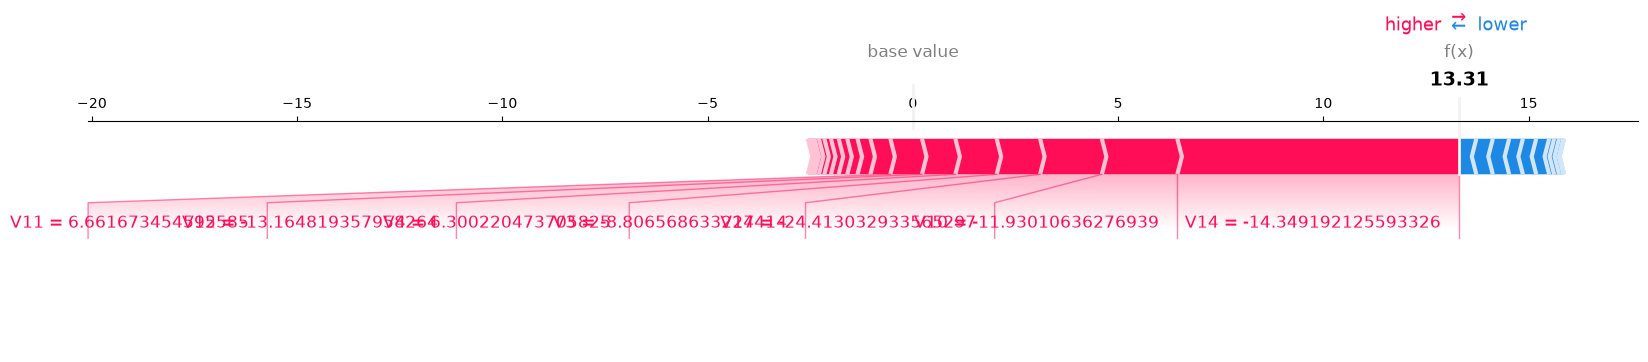

In [12]:
# True Positive: correctly identified fraud
i = list(credit_examples.keys()).index('true_positive')
idx = credit_examples['true_positive']
print(f"True label: {y_credit_test.iloc[idx]}, Predicted: {credit_results['y_pred'][idx]}, "
      f"P(fraud)={credit_results['y_proba'][idx]:.4f}")

shap.force_plot(
    credit_explainer.expected_value, credit_shap_examples[i], credit_example_rows.iloc[i],
    matplotlib=True, show=False
)
plt.savefig('../reports/figures/credit_shap_force_true_positive.png', bbox_inches='tight')
plt.show()

True label: 0, Predicted: 1, P(fraud)=0.9999


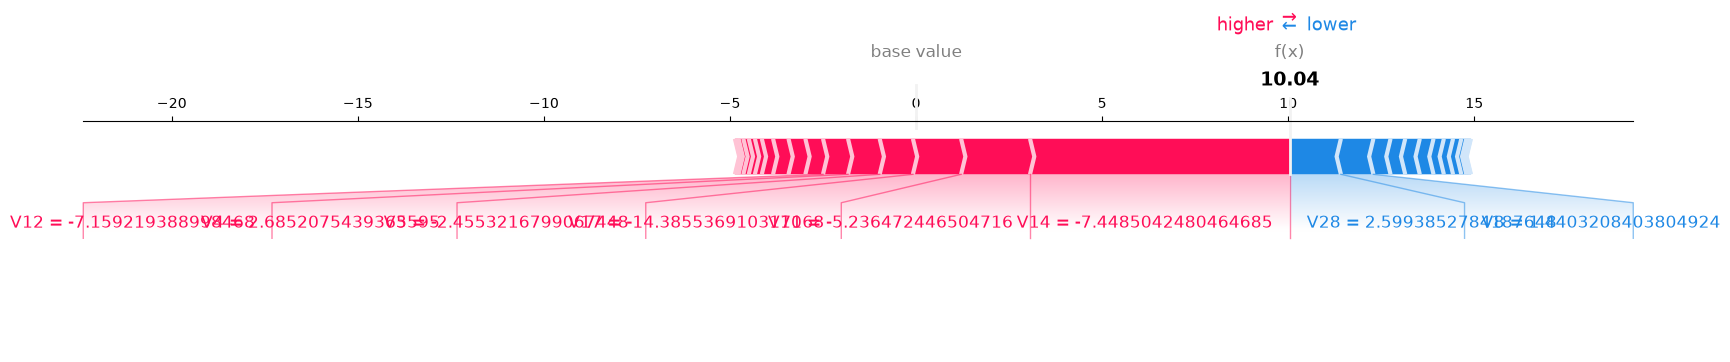

In [13]:
# False Positive: legitimate transaction flagged as fraud
i = list(credit_examples.keys()).index('false_positive')
idx = credit_examples['false_positive']
print(f"True label: {y_credit_test.iloc[idx]}, Predicted: {credit_results['y_pred'][idx]}, "
      f"P(fraud)={credit_results['y_proba'][idx]:.4f}")

shap.force_plot(
    credit_explainer.expected_value, credit_shap_examples[i], credit_example_rows.iloc[i],
    matplotlib=True, show=False
)
plt.savefig('../reports/figures/credit_shap_force_false_positive.png', bbox_inches='tight')
plt.show()

True label: 1, Predicted: 0, P(fraud)=0.0000


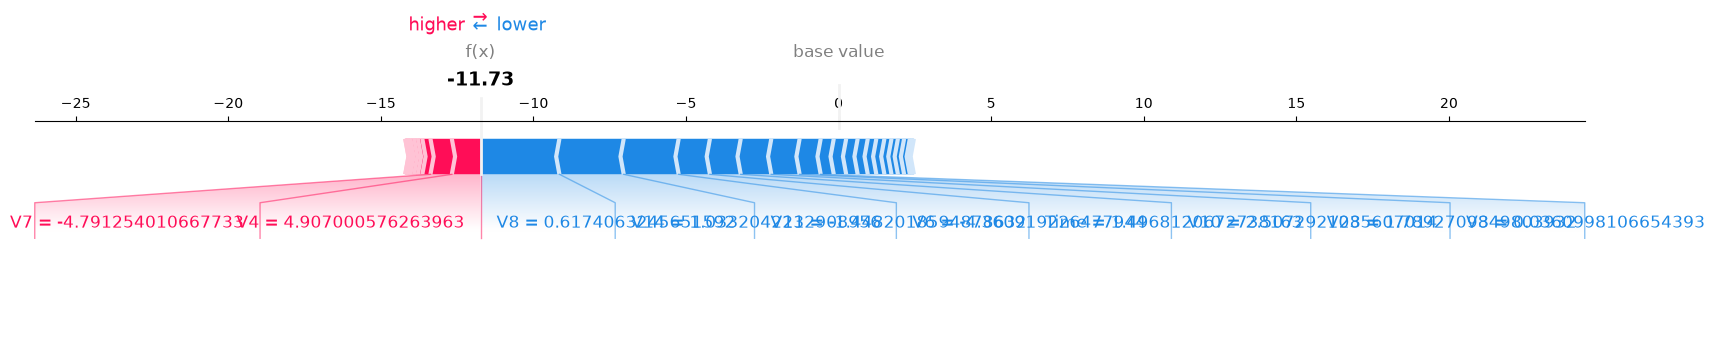

In [14]:
# False Negative: missed fraud
i = list(credit_examples.keys()).index('false_negative')
idx = credit_examples['false_negative']
print(f"True label: {y_credit_test.iloc[idx]}, Predicted: {credit_results['y_pred'][idx]}, "
      f"P(fraud)={credit_results['y_proba'][idx]:.4f}")

shap.force_plot(
    credit_explainer.expected_value, credit_shap_examples[i], credit_example_rows.iloc[i],
    matplotlib=True, show=False
)
plt.savefig('../reports/figures/credit_shap_force_false_negative.png', bbox_inches='tight')
plt.show()

### Reading the Individual Force Plots (Credit Card Data)

| Example | True / Predicted | P(fraud) | Top contributing features (SHAP) |
|---|---|---|---|
| **True Positive** (row 18427) | Fraud / Fraud | 1.0000 | `V14` (+6.86), `V10` (+1.84), `V17` (+1.51), `V3` (+1.06), `V4` (+1.01) — an extreme outlier across *every one* of the top-5 SHAP drivers simultaneously, producing one of the most confident fraud predictions in the test set. |
| **False Positive** (row 33810) | Legit / Fraud | 0.9999 | `V14` (+6.98) and `V10` (+1.85) are *even larger* here than in the true-positive case — this legitimate transaction has the same extreme-PCA-outlier profile the model has learned to associate with fraud. `V28` (-1.37) and `V8` (-0.87) pull slightly back toward "legitimate" but are not enough to overcome `V14`/`V10`. |
| **False Negative** (row 50807) | Fraud / Legit | 0.0000 | Every top contributor (`V8` -2.59, `V14` -2.11, `V11` -1.80, `V6` -1.02, `Time` -1.01) pushes *toward* "legitimate" — this fraud transaction simply does not resemble the PCA-outlier pattern the model has learned, so it passes through completely undetected. |

**Implication:** the XGBoost model has effectively learned "is this transaction a multi-dimensional PCA outlier, especially on `V14`?" as its primary fraud heuristic. This catches the dominant fraud pattern in the data extremely well (AUC-PR 0.816), but a fraud pattern that does *not* manifest as a `V14`/`V10`/`V17` outlier (the false negative) is essentially invisible to the model — and an unusual-but-legitimate transaction that *does* resemble that outlier profile (the false positive) gets blocked.

---
## Business Recommendations

Translating the SHAP findings above into concrete, actionable steps for Adey Innovations Inc.:

1. **Add step-up verification for "fast first purchase" e-commerce transactions.** `time_since_signup` is the #3 SHAP driver for the fraud model, and both the true-positive and false-positive examples show that a purchase made within minutes of account creation strongly increases the predicted fraud probability. **Recommendation:** transactions occurring within (e.g.) 1 hour of signup should automatically receive additional verification (e.g., email/SMS confirmation or a temporary spending cap), rather than being silently blocked — this captures the true-positive pattern while reducing the false-positive risk of blocking a genuinely new customer's first purchase outright.

2. **Treat device/IP-sharing as a risk-scoring input, not an automatic block.** `device_sharing_count` is the #1 driver for both built-in importance and SHAP, but the false-positive example shows that legitimate users (e.g., shared family or office devices) can also share a device with many accounts. **Recommendation:** use `device_sharing_count` and `ip_sharing_count` to *raise* a transaction's risk score and route it to manual review or step-up authentication, rather than auto-declining — this preserves the strong fraud signal while reducing customer friction for shared-device households.

3. **Build a secondary detection model for "low-velocity" fraud.** The false-negative example shows that fraud which does *not* exhibit device-sharing or rapid-signup behavior (e.g., a single stolen identity used once, from a low-risk country) is currently missed entirely. **Recommendation:** since this is exactly the kind of fraud that velocity-based features cannot see, invest in complementary signals (e.g., behavioral biometrics, payment-instrument reputation, or cross-referencing with known compromised-credential lists) to cover this blind spot.

4. **For the credit card stream, monitor `V14`, `V4`, `V10`, `V12`, and `V11` as a composite "outlier score" for real-time alerting.** These five PCA components account for the overwhelming majority of both gain-based and SHAP importance (`V14` alone = 63% of gain importance), and the true-positive/false-positive examples show fraud (and fraud-like legitimate transactions) are extreme multi-dimensional outliers on this set. **Recommendation:** surface a simple composite "PCA outlier score" derived from these five components to the fraud-review team as a fast triage signal, alongside the full model score.

5. **Set the operating threshold using the Precision-Recall curve, not a default 0.5 cutoff — especially for the credit card model.** At the default threshold, Logistic Regression's precision on the credit card data is only 5.3% (≈18 false alarms per true fraud caught), which would be operationally unworkable. XGBoost's PR curve (AUC-PR = 0.816) shows precision stays above ~75% out to a recall of roughly 80%. **Recommendation:** the fraud-operations team should choose an operating threshold along this curve based on their review-capacity budget (false alerts per day they can realistically investigate), rather than defaulting to 0.5 — and should re-validate this threshold periodically as transaction volume and fraud patterns evolve.

6. **Re-run SHAP analysis periodically as a model-monitoring tool.** Because the false-positive and false-negative examples above reveal *systematic* blind spots (shared-device legitimate users, low-velocity fraud), tracking how the top SHAP drivers shift over time can serve as an early-warning system — e.g., if `device_sharing_count`'s share of total SHAP impact suddenly drops, it may indicate fraudsters have adapted to avoid that signal, prompting a model refresh.